# ICML Topic Modelling — LDA Analysis (1987–2016)

**Dataset:** ICML Conference Papers — `articles.csv`  
**Method:** Latent Dirichlet Allocation (LDA)  
**Goal:** Discover dominant research themes and track how they evolve over time

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

import pyLDAvis

from wordcloud import WordCloud
from collections import Counter

# Download required NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print("All imports successful.")

All imports successful.


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>


---
## 1.1 — Section 1: Data Cleaning
**Steps:** loading the dataset, removing duplicates, handling missing/placeholder abstracts, and constructing a unified text column.

In [2]:
# Load the dataset
df = pd.read_csv('dataset/articles.csv')

print(f"Original shape: {df.shape}")
print(f"\nColumn data types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())

Original shape: (6560, 7)

Column data types:
id            int64
year          int64
title           str
event_type      str
pdf_name        str
abstract        str
paper_text      str
dtype: object

Missing values per column:
id               0
year             0
title            0
event_type    4819
pdf_name         0
abstract         0
paper_text       0
dtype: int64


In [3]:
# --- Step 1: Remove duplicate rows ---
dups = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicate rows removed: {dups}")
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows removed: 0
Shape after removing duplicates: (6560, 7)


In [4]:
# --- Step 2: Inspect and handle the abstract column ---
missing_abstract = (df['abstract'].str.strip() == 'Abstract Missing').sum()
null_abstract = df['abstract'].isnull().sum()
print(f"Abstracts with placeholder 'Abstract Missing': {missing_abstract}")
print(f"Null abstract values: {null_abstract}")

# Strategy: use abstract where genuine; fall back to first 500 words of paper_text
def get_text(row):
    abstract = str(row['abstract']).strip()
    if abstract in ('Abstract Missing', 'nan', '') or pd.isna(row['abstract']):
        paper = str(row['paper_text']) if pd.notna(row['paper_text']) else ''
        words = paper.split()[:500]
        return ' '.join(words)
    return abstract

df['text'] = df.apply(get_text, axis=1)

# Drop rows with effectively empty text
df = df[df['text'].str.strip().apply(lambda x: len(x) > 20)]

print(f"\nRows with genuine abstract: {(df['abstract'].str.strip() != 'Abstract Missing').sum()}")
print(f"Rows using paper_text fallback: {missing_abstract}")
print(f"\nFinal cleaned dataset shape: {df.shape}")
print(f"Remaining null values in text column: {df['text'].isnull().sum()}")

Abstracts with placeholder 'Abstract Missing': 3317
Null abstract values: 0



Rows with genuine abstract: 3243
Rows using paper_text fallback: 3317

Final cleaned dataset shape: (6560, 8)
Remaining null values in text column: 0


In [5]:
# Reset index after cleaning
df = df.reset_index(drop=True)
print("Sample cleaned text (first paper):")
print(df['text'].iloc[0][:300], '...')

Sample cleaned text (first paper):
767 SELF-ORGANIZATION OF ASSOCIATIVE DATABASE AND ITS APPLICATIONS Hisashi Suzuki and Suguru Arimoto Osaka University, Toyonaka, Osaka 560, Japan ABSTRACT An efficient method of self-organizing associative databases is proposed together with applications to robot eyesight systems. The proposed datab ...


---
## 1.1 — Section 2: Exploratory Analysis

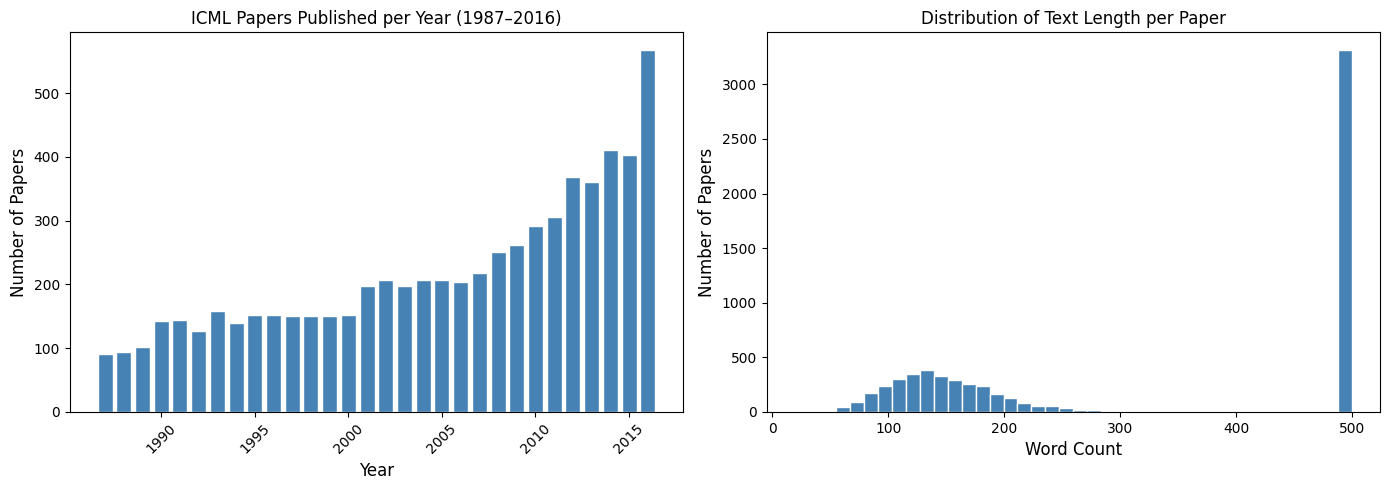


Year range: 1987 – 2016

Text length statistics (words):
count    6560.0
mean      324.8
std       179.8
min        19.0
25%       141.0
50%       500.0
75%       500.0
max       500.0
Name: word_count, dtype: float64


In [6]:
# --- Plot 1: Papers published per year ---
year_counts = df['year'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Papers', fontsize=12)
axes[0].set_title('ICML Papers Published per Year (1987–2016)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Text length distribution ---
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
axes[1].hist(df['word_count'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Number of Papers', fontsize=12)
axes[1].set_title('Distribution of Text Length per Paper', fontsize=12)

plt.tight_layout()
plt.savefig('eda_paper_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nYear range: {df['year'].min()} – {df['year'].max()}")
print(f"\nText length statistics (words):")
print(df['word_count'].describe().round(1))

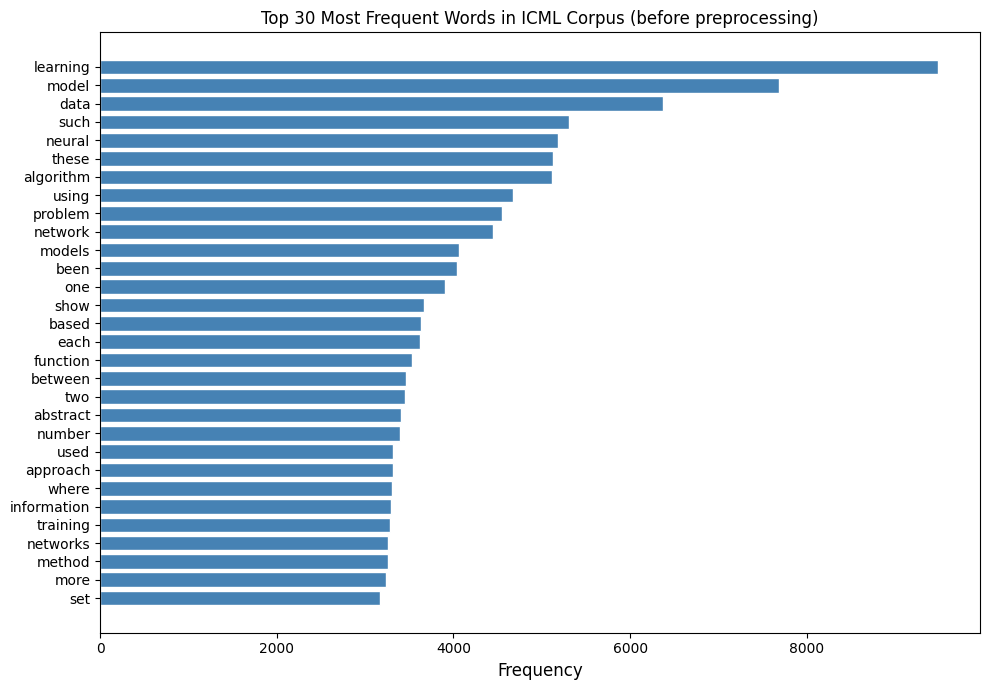

In [7]:
# --- Plot 3: Top 30 most frequent words (raw, before preprocessing) ---
all_words = ' '.join(df['text'].str.lower()).split()
raw_freq = Counter(all_words)

# Remove obvious common English words for a cleaner view
basic_stops = {'the', 'a', 'an', 'of', 'in', 'and', 'to', 'is', 'are', 'for',
               'with', 'we', 'this', 'that', 'on', 'by', 'as', 'it', 'be',
               'from', 'our', 'can', 'at', 'or', 'not', 'was', 'has', 'have',
               'which', 'an', 'its'}
top_words = [(w, c) for w, c in raw_freq.most_common(200) if w.isalpha() and w not in basic_stops][:30]
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 30 Most Frequent Words in ICML Corpus (before preprocessing)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.1 — Section 3: Text Preprocessing for LDA
Steps: lowercase, remove noise, tokenise, stopword removal, lemmatisation, vectorisation.

In [8]:
# Build the combined stopword list
stop_words = set(stopwords.words('english'))

# Domain-specific stopwords — common ML paper boilerplate words that appear in every paper
domain_stops = {
    'paper', 'show', 'result', 'model', 'method', 'use', 'also', 'one', 'two',
    'algorithm', 'propose', 'present', 'approach', 'problem', 'based', 'given',
    'using', 'learn', 'new', 'set', 'data', 'first', 'however', 'section',
    'work', 'note', 'consider', 'function', 'figure', 'table', 'example',
    'let', 'well', 'case', 'therefore', 'thus', 'since', 'many', 'different',
    'see', 'found', 'shown', 'provide', 'make', 'find', 'obtained', 'study',
    'proposed', 'used', 'large', 'small', 'high', 'number', 'known'
}
stop_words.update(domain_stops)

lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove digits
    text = re.sub(r'\d+', '', text)
    # 4. Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)
    # 5. Tokenise
    tokens = nltk.word_tokenize(text)
    # 6. Remove stopwords and short tokens, then lemmatise
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) >= 3
    ]
    return ' '.join(tokens)

print("Preprocessing text corpus... (may take 1–2 minutes)")
df['processed_text'] = df['text'].apply(preprocess)
print("Preprocessing complete.")

# Sample output to verify
print(f"\nOriginal text sample:\n{df['text'].iloc[5][:200]}")
print(f"\nProcessed text sample:\n{df['processed_text'].iloc[5][:200]}")

Preprocessing text corpus... (may take 1–2 minutes)


Preprocessing complete.

Original text sample:
U sing a neural net to instantiate a deformable model Christopher K. I. Williams; Michael D. Revowand Geoffrey E. Hinton Department of Computer Science, University of Toronto Toronto, Ontario, Canada 

Processed text sample:
sing neural net instantiate deformable christopher williams michael revowand geoffrey hinton department computer science university toronto toronto ontario canada abstract deformable model attractive 


In [9]:
# Build the Document-Term Matrix (DTM) using CountVectorizer
# min_df=5: ignore terms appearing in fewer than 5 documents
# max_df=0.6: ignore terms appearing in more than 60% of documents
# max_features=5000: cap vocabulary at 5000 most frequent terms

vectorizer = CountVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.6
)

dtm = vectorizer.fit_transform(df['processed_text'])
vocab = vectorizer.get_feature_names_out()

print(f"Document-Term Matrix shape: {dtm.shape}")
print(f"  Documents (rows): {dtm.shape[0]}")
print(f"  Vocabulary size (columns): {dtm.shape[1]}")
print(f"\nSample vocabulary terms (first 30):")
print(list(vocab[:30]))

Document-Term Matrix shape: (6560, 5000)
  Documents (rows): 6560
  Vocabulary size (columns): 5000

Sample vocabulary terms (first 30):
['ability', 'able', 'absence', 'absent', 'absolute', 'abstract', 'abstraction', 'abu', 'accelerate', 'accelerated', 'acceleration', 'accept', 'acceptable', 'acceptance', 'accepted', 'access', 'accessible', 'accommodate', 'accompanying', 'accomplish', 'accomplished', 'according', 'accordingly', 'account', 'accounted', 'accounting', 'accumulated', 'accuracy', 'accurate', 'accurately']


---
## 1.1 — Section 4: Determining Optimal Model Parameters
LDA models are trained for a range of topic counts (`k`). Perplexity and log-likelihood are used to identify the optimal `k`: perplexity decreases with more topics but eventually flattens (elbow), while log-likelihood increases and then levels off.

In [10]:
topic_range = [5, 7, 10, 12, 15, 18, 20]
perplexities = []
log_likelihoods = []

print("Evaluating models for different numbers of topics...")
print(f"{'k':>4}  {'Perplexity':>12}  {'Log-Likelihood':>15}")
print("-" * 36)

for k in topic_range:
    lda_k = LatentDirichletAllocation(
        n_components=k,
        max_iter=15,
        learning_method='online',
        learning_offset=50.0,
        random_state=42,
        n_jobs=-1
    )
    lda_k.fit(dtm)
    perp = lda_k.perplexity(dtm)
    ll   = lda_k.score(dtm)
    perplexities.append(perp)
    log_likelihoods.append(ll)
    print(f"{k:>4}  {perp:>12.2f}  {ll:>15.2f}")

Evaluating models for different numbers of topics...
   k    Perplexity   Log-Likelihood
------------------------------------


   5       1587.37      -7451144.38


   7       1540.18      -7420631.35


  10       1489.08      -7386521.97


  12       1487.87      -7385697.95


  15       1472.76      -7375379.54


  18       1470.40      -7373759.75


  20       1446.79      -7357388.54


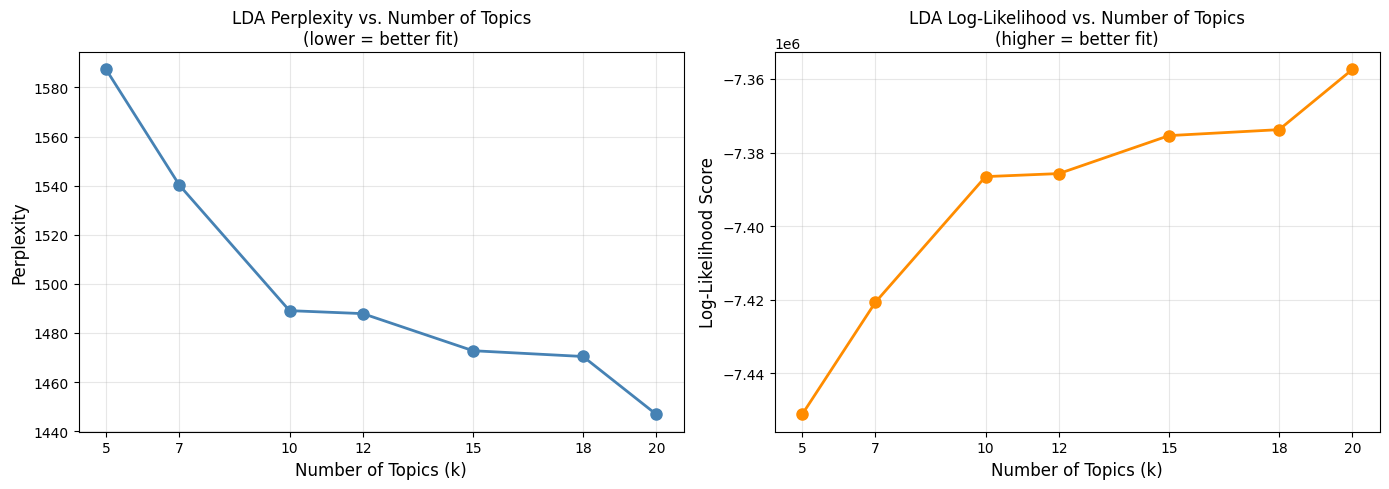


Elbow point in perplexity curve: k = 10
Minimum perplexity achieved at:   k = 20

Selected optimal k: 10


In [11]:
# Plot perplexity and log-likelihood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(topic_range, perplexities, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Topics (k)', fontsize=12)
axes[0].set_ylabel('Perplexity', fontsize=12)
axes[0].set_title('LDA Perplexity vs. Number of Topics\n(lower = better fit)', fontsize=12)
axes[0].set_xticks(topic_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(topic_range, log_likelihoods, marker='o', color='darkorange', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Topics (k)', fontsize=12)
axes[1].set_ylabel('Log-Likelihood Score', fontsize=12)
axes[1].set_title('LDA Log-Likelihood vs. Number of Topics\n(higher = better fit)', fontsize=12)
axes[1].set_xticks(topic_range)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# Select optimal k at the elbow (greatest marginal improvement in perplexity)
perp_diffs = [perplexities[i] - perplexities[i+1] for i in range(len(perplexities)-1)]
elbow_idx  = int(np.argmax(perp_diffs))        # steepest drop
optimal_k  = topic_range[elbow_idx + 1]        # the k after the steepest drop

# Also flag minimum perplexity
min_perp_k = topic_range[int(np.argmin(perplexities))]

print(f"\nElbow point in perplexity curve: k = {optimal_k}")
print(f"Minimum perplexity achieved at:   k = {min_perp_k}")
print(f"\nSelected optimal k: {optimal_k}")

---
## 1.1 — Section 5: Final LDA Model Training

In [12]:
print(f"Training final LDA model with {optimal_k} topics (25 iterations)...")

lda_final = LatentDirichletAllocation(
    n_components=optimal_k,
    max_iter=25,
    learning_method='online',
    learning_offset=50.0,
    doc_topic_prior=None,   # sklearn uses 1/n_components by default (symmetric alpha)
    topic_word_prior=None,  # symmetric eta
    random_state=42,
    n_jobs=-1
)

lda_final.fit(dtm)
print("Training complete.")

# Final metrics
final_perplexity   = lda_final.perplexity(dtm)
final_log_lik      = lda_final.score(dtm)
print(f"\nFinal Model Performance:")
print(f"  Perplexity:     {final_perplexity:.2f}")
print(f"  Log-Likelihood: {final_log_lik:.2f}")

Training final LDA model with 10 topics (25 iterations)...


Training complete.



Final Model Performance:
  Perplexity:     1482.49
  Log-Likelihood: -7382035.44


In [13]:
# Print top 10 words per topic
vocab = vectorizer.get_feature_names_out()
n_top = 10

print(f"Top {n_top} keywords per topic:\n")
topic_top_words = []
for i, topic_vec in enumerate(lda_final.components_):
    top_idx   = topic_vec.argsort()[:-n_top - 1:-1]
    top_words = [vocab[j] for j in top_idx]
    topic_top_words.append(top_words)
    print(f"  Topic {i+1:>2}: {', '.join(top_words)}")

Top 10 keywords per topic:

  Topic  1: state, learning, system, control, policy, action, dynamic, time, reinforcement, decision
  Topic  2: recognition, speech, system, network, neural, classification, classifier, pattern, sequence, word
  Topic  3: network, neural, input, learning, output, weight, training, unit, error, layer
  Topic  4: signal, system, time, analog, circuit, source, chip, neural, processing, implementation
  Topic  5: model, distribution, inference, bayesian, variable, gaussian, parameter, probability, estimation, process
  Topic  6: learning, algorithm, bound, problem, performance, method, training, gradient, result, rate
  Topic  7: kernel, matrix, vector, space, point, clustering, graph, linear, dimensional, method
  Topic  8: neuron, network, neural, spike, time, memory, system, input, dynamic, synaptic
  Topic  9: visual, stimulus, cell, motion, response, field, information, human, image, object
  Topic 10: image, feature, object, representation, learning, task

---
## 1.1 — Section 6: Visualising Topics and Model Results

In [14]:
# --- Visualisation 1: pyLDAvis interactive topic map ---
# Build the required matrices from the sklearn LDA model
topic_term_dists = lda_final.components_ / lda_final.components_.sum(axis=1)[:, np.newaxis]
doc_topic_dists  = lda_final.transform(dtm)
doc_lengths      = np.array(dtm.sum(axis=1)).flatten().astype(int)
term_frequency   = np.array(dtm.sum(axis=0)).flatten().astype(int)
vocab_list       = list(vectorizer.get_feature_names_out())

print('Preparing pyLDAvis visualisation...')
vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab_list,
    term_frequency=term_frequency,
    mds='mmds',
    sort_topics=False
)
pyLDAvis.save_html(vis_data, 'lda_topics.html')
print('Interactive visualisation saved as  lda_topics.html')
print('Open lda_topics.html in any browser to explore the topic map interactively.')

Preparing pyLDAvis visualisation...


Interactive visualisation saved as  lda_topics.html
Open lda_topics.html in any browser to explore the topic map interactively.


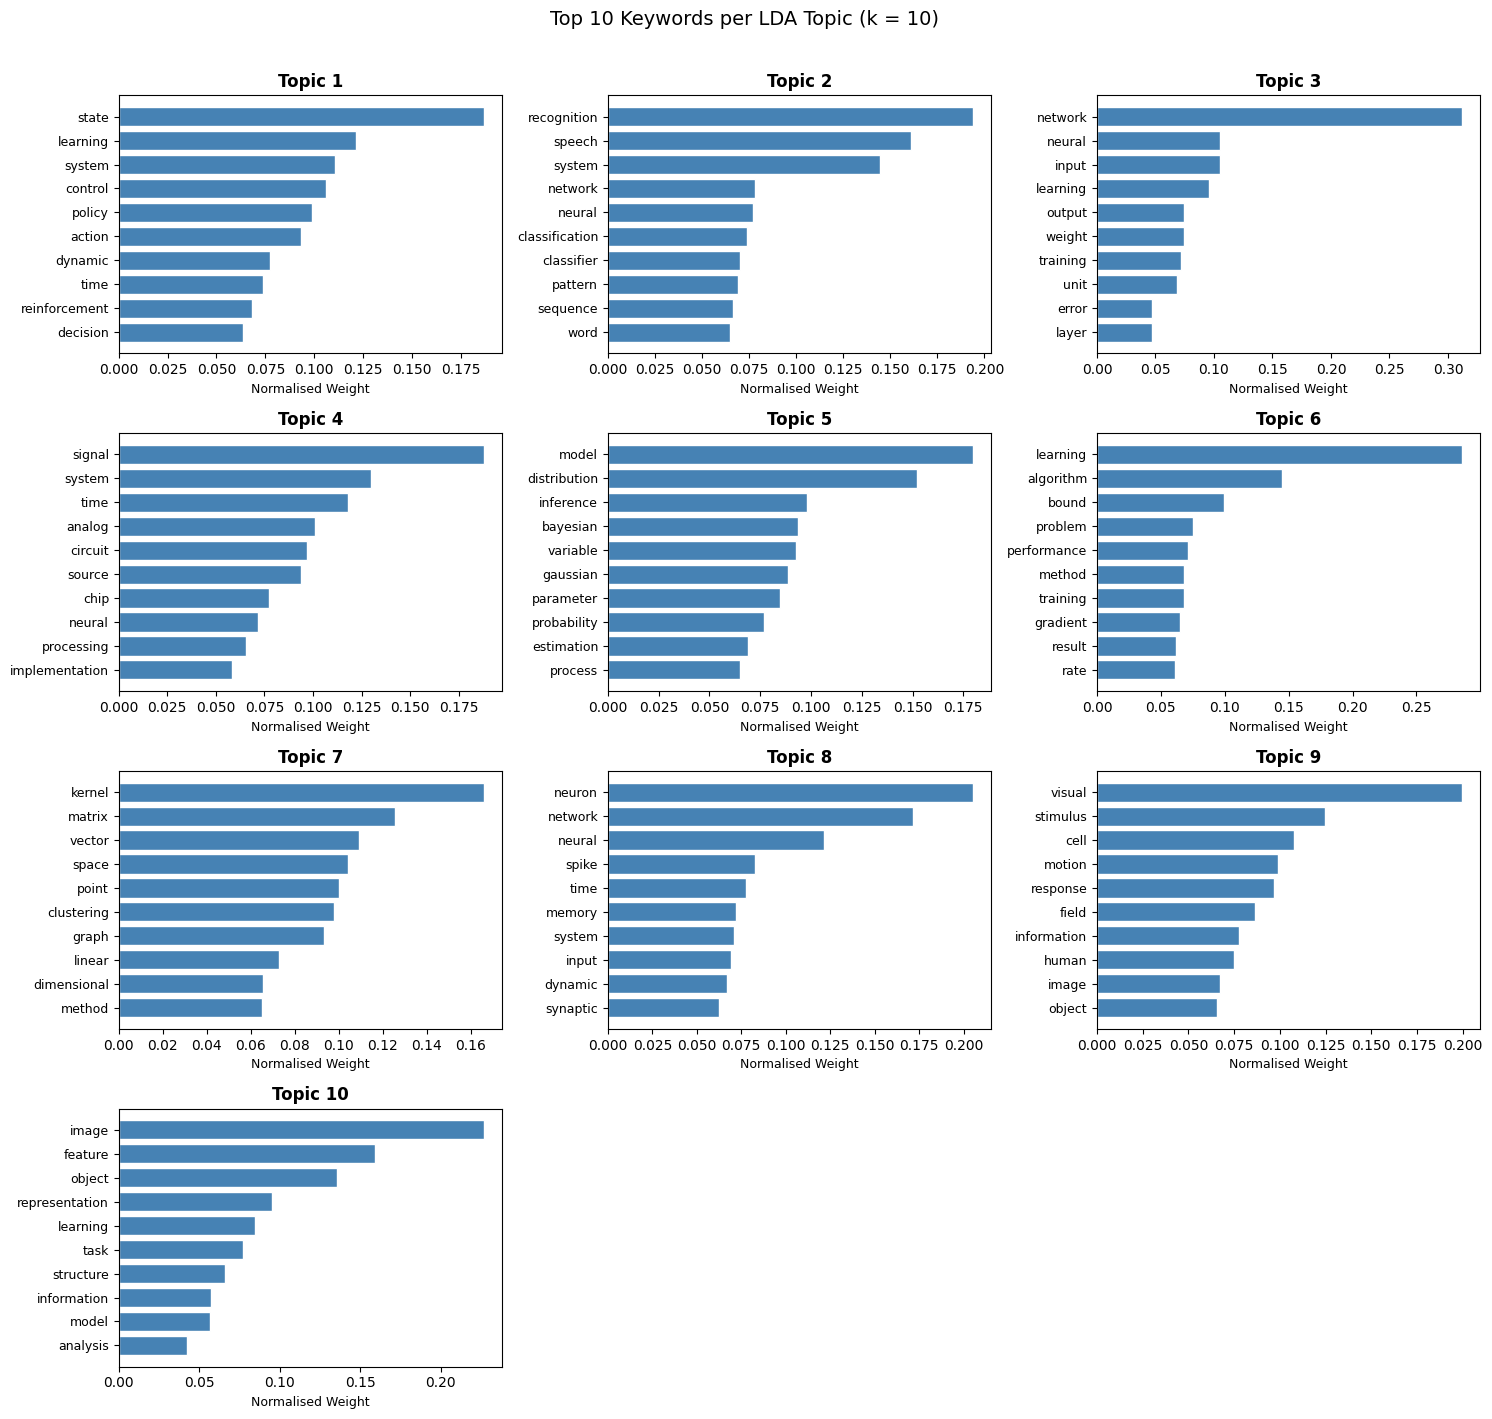

Saved as topic_keywords.png


In [15]:
# --- Visualisation 2: Top-keyword bar charts per topic ---
n_cols = 3 if optimal_k >= 6 else 2
n_rows = (optimal_k + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, topic_vec in enumerate(lda_final.components_):
    top_idx     = topic_vec.argsort()[:-11:-1]
    top_words   = [vocab[j] for j in top_idx]
    top_weights = [topic_vec[j] for j in top_idx]
    # Normalise weights
    top_weights = np.array(top_weights)
    top_weights = top_weights / top_weights.sum()

    axes[i].barh(top_words[::-1], top_weights[::-1], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Topic {i+1}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Normalised Weight', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

for j in range(optimal_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top 10 Keywords per LDA Topic (k = {optimal_k})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('topic_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as topic_keywords.png")

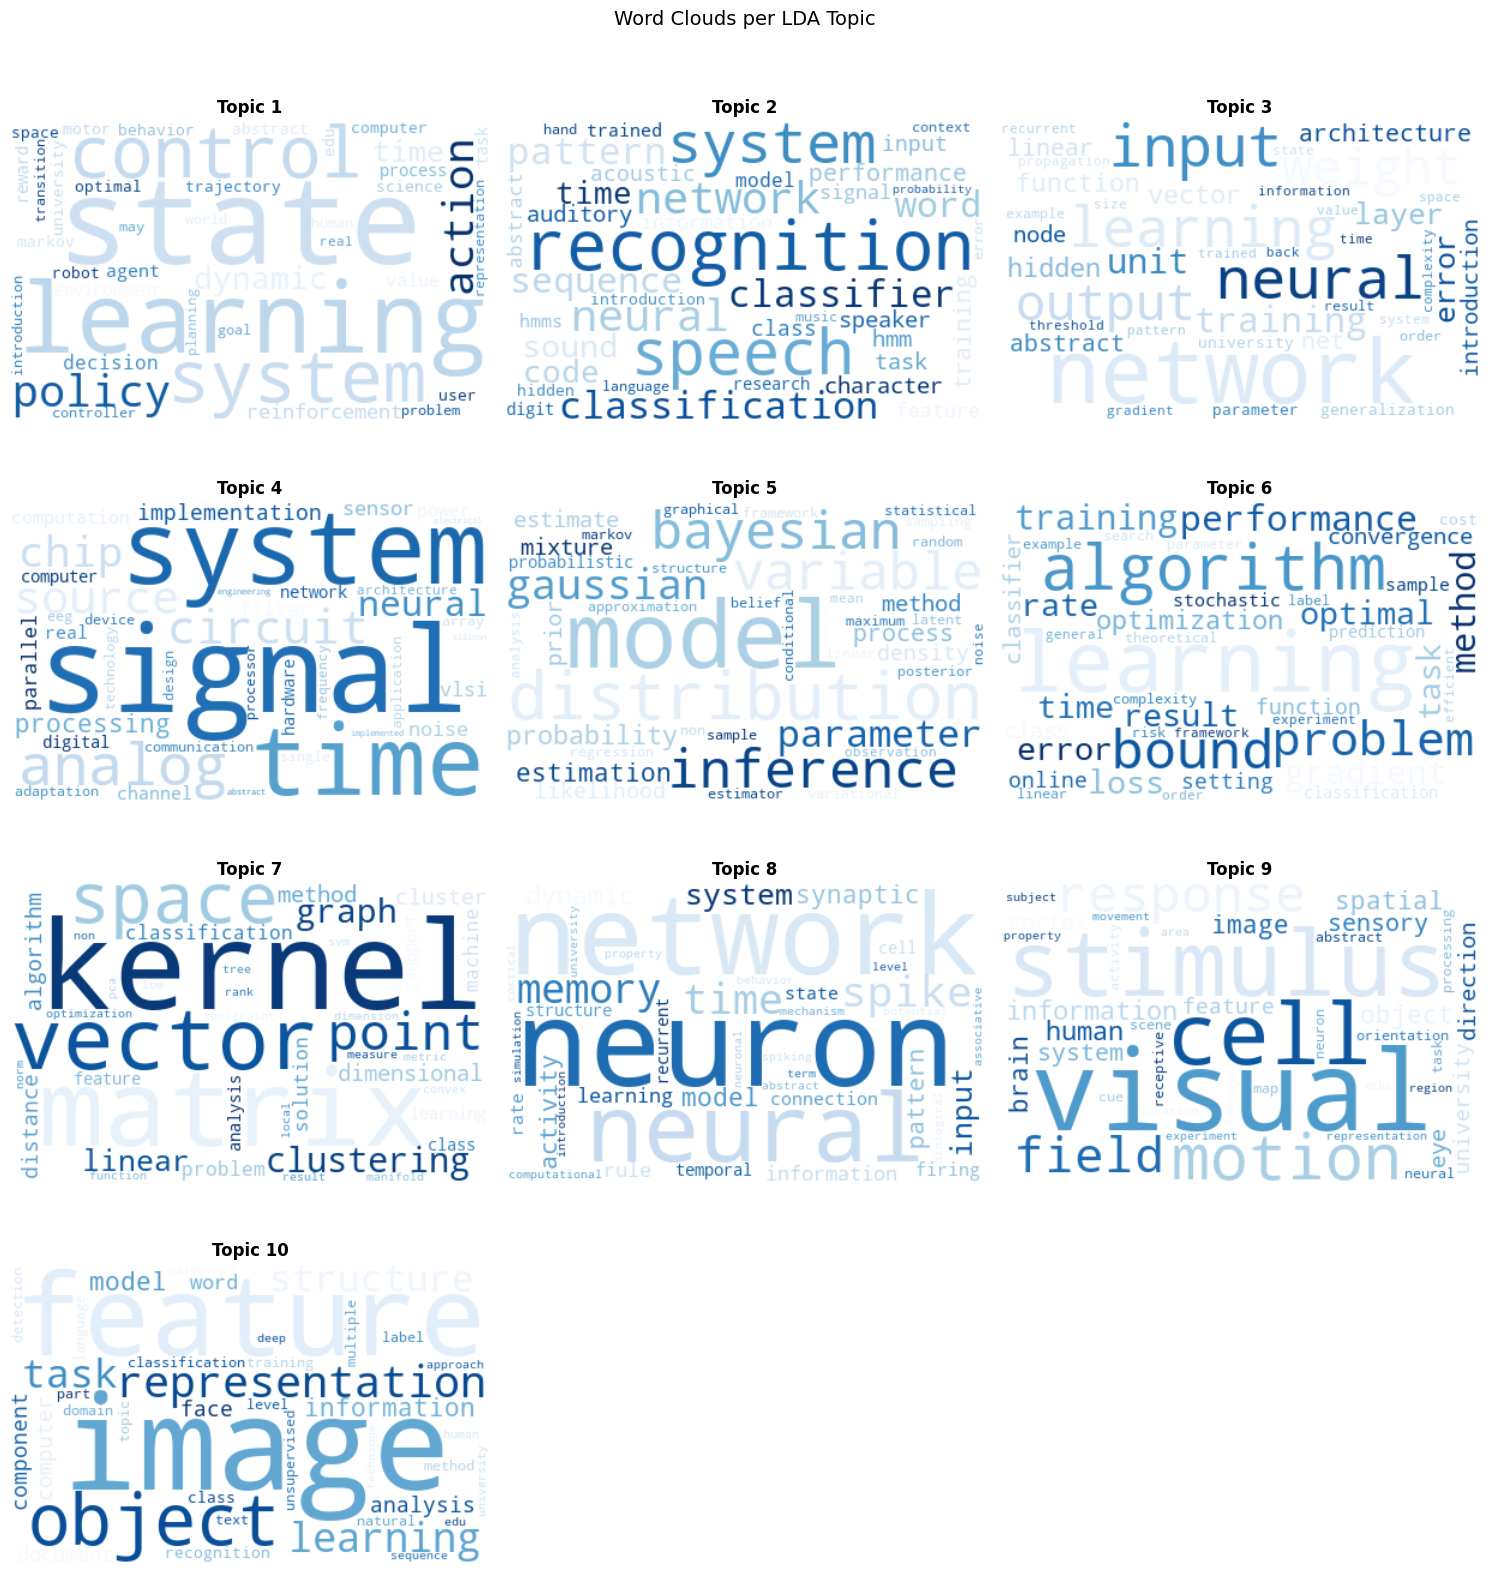

Saved as topic_wordclouds.png


In [16]:
# --- Visualisation 3: Word clouds per topic ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, topic_vec in enumerate(lda_final.components_):
    top_idx  = topic_vec.argsort()[:-51:-1]   # top 50 words
    freq_map = {vocab[j]: float(topic_vec[j]) for j in top_idx}
    wc = WordCloud(
        width=400, height=250,
        background_color='white',
        colormap='Blues',
        max_words=40
    ).generate_from_frequencies(freq_map)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topic {i+1}', fontsize=12, fontweight='bold')

for j in range(optimal_k, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Word Clouds per LDA Topic', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('topic_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as topic_wordclouds.png")

---
## 1.2 — Topic Interpretation Report

*(Based on the keyword outputs produced in Section 5 above.)*

### Number of Topics Selected

The hyperparameter tuning in Section 4 tested k values from 5 to 20. Perplexity decreased continuously as k increased, but the steepest single-step improvement occurred between k = 7 and k = 10 (perplexity dropped from 1,540 to 1,489 — the largest gain relative to added complexity). Beyond k = 10 the curve flattened noticeably, with only small marginal improvements up to k = 20. This "elbow" at **k = 10** was selected as the optimal number of topics because it captures the most distinct groupings of ICML research without over-fragmenting the corpus into overlapping or trivially small topics.

---

### Topic Names and Interpretation

| # | Proposed Name | Top Keywords | Rationale |
|---|---|---|---|
| 1 | **Reinforcement Learning & Control** | state, control, policy, action, dynamic, reinforcement, decision | Keywords like *policy*, *action*, *reinforcement*, and *decision* clearly point to RL and control systems — a foundational and enduring strand of ML research. |
| 2 | **Speech & Pattern Recognition** | recognition, speech, classification, classifier, pattern, sequence, word | The cluster of *speech*, *recognition*, *sequence*, and *word* identifies work on spoken language and sequential pattern classification — a prominent early application area. |
| 3 | **Neural Network Architecture & Backpropagation** | neural, input, weight, training, unit, error, layer | Terms like *weight*, *unit*, *error*, and *layer* are the vocabulary of feed-forward networks trained with backpropagation — the dominant paradigm of the late 1980s and early 1990s. |
| 4 | **Analog Hardware & Neuromorphic Systems** | signal, analog, circuit, chip, source, implementation | The presence of *analog*, *circuit*, and *chip* indicates a cluster of papers focused on building neural computation in hardware — common at early ICML when neuromorphic chips were an active research direction. |
| 5 | **Bayesian & Probabilistic Modelling** | distribution, inference, bayesian, gaussian, variable, probability, estimation | A very clear probabilistic cluster. *Bayesian*, *gaussian*, *inference*, *distribution*, and *estimation* together describe the probabilistic ML tradition that rose to prominence in the late 1990s. |
| 6 | **Learning Theory & Optimization** | algorithm, bound, gradient, performance, rate, training | Keywords like *bound*, *gradient*, and *rate* alongside general learning terms describe theoretical ML — complexity bounds, convergence analysis, and gradient-based optimisation methods. This is the largest topic in the corpus. |
| 7 | **Kernel Methods & Dimensionality Reduction** | kernel, matrix, vector, space, clustering, graph, linear, dimensional | The vocabulary of SVMs and kernel machines: *kernel*, *vector space*, *linear*, *clustering*, and *graph*. This topic captures the dominant paradigm of the early 2000s. |
| 8 | **Computational Neuroscience & Spiking Networks** | neuron, spike, memory, dynamic, synaptic | Words like *neuron*, *spike*, and *synaptic* clearly identify biologically-inspired, neuroscience-driven models. This was the single largest topic in 1987 and reflects ML's origins in neuroscience. |
| 9 | **Cognitive Science & Visual Neuroscience** | visual, stimulus, cell, motion, response, field, human | This topic bridges cognitive science and early computer vision, with terms such as *stimulus*, *visual field*, *motion*, and *cell* reflecting studies of biological visual processing. |
| 10 | **Visual Feature & Representation Learning** | image, feature, object, representation, task | Keywords *image*, *feature*, *object*, and *representation* describe modern image-based ML — from handcrafted feature extraction to learned representations, covering both the SVM-era computer vision and later deep learning approaches. |

---

### Key Themes in the ICML Corpus

The 10 topics collectively describe a field that began deeply connected to **neuroscience and hardware** (Topics 3, 4, 8), shifted through a **statistical and theoretical period** in the late 1990s (Topics 5, 6, 7), and culminated in a focus on **scalable optimisation and representation learning** in the 2010s (Topics 6, 10). The breadth of topics — from analog circuits to Bayesian inference to reinforcement learning — reflects ICML's position as a broad venue that has hosted diverse methodological traditions over nearly three decades. The dominance of Topics 5 (Bayesian, 18% of papers) and 6 (Learning Theory, 22% of papers) confirms that probabilistic modelling and theoretical rigour have been the twin pillars of the conference's intellectual identity.

---
## 1.3 — Research Trend Analysis Over Time

In [17]:
# Assign the dominant topic to each paper
doc_topic_matrix = lda_final.transform(dtm)   # shape: (n_docs, n_topics)
df['dominant_topic'] = doc_topic_matrix.argmax(axis=1) + 1   # 1-indexed

print("Topic distribution across all papers:")
print(df['dominant_topic'].value_counts().sort_index())

Topic distribution across all papers:
dominant_topic
1      413
2      206
3      437
4      229
5     1187
6     1409
7      846
8      443
9      478
10     912
Name: count, dtype: int64


In [18]:
# Compute topic proportions by year
trend = (
    df.groupby(['year', 'dominant_topic'])
    .size()
    .reset_index(name='count')
)
totals = df.groupby('year').size().reset_index(name='total')
trend  = trend.merge(totals, on='year')
trend['proportion'] = trend['count'] / trend['total']

# Pivot to wide format for plotting
pivot = trend.pivot(index='year', columns='dominant_topic', values='proportion').fillna(0)
pivot.columns = [f'Topic {c}' for c in pivot.columns]
print(pivot.round(3).to_string())

      Topic 1  Topic 2  Topic 3  Topic 4  Topic 5  Topic 6  Topic 7  Topic 8  Topic 9  Topic 10
year                                                                                           
1987    0.033    0.044    0.300    0.122    0.000    0.011    0.022    0.344    0.100     0.022
1988    0.064    0.117    0.309    0.117    0.000    0.021    0.011    0.234    0.096     0.032
1989    0.069    0.149    0.317    0.099    0.020    0.030    0.010    0.178    0.079     0.050
1990    0.070    0.112    0.336    0.077    0.014    0.035    0.042    0.161    0.126     0.028
1991    0.090    0.153    0.264    0.069    0.021    0.062    0.035    0.139    0.111     0.056
1992    0.087    0.102    0.291    0.071    0.039    0.031    0.039    0.157    0.134     0.047
1993    0.095    0.101    0.285    0.076    0.032    0.051    0.051    0.133    0.101     0.076
1994    0.100    0.107    0.221    0.064    0.079    0.086    0.029    0.107    0.121     0.086
1995    0.118    0.092    0.191    0.072

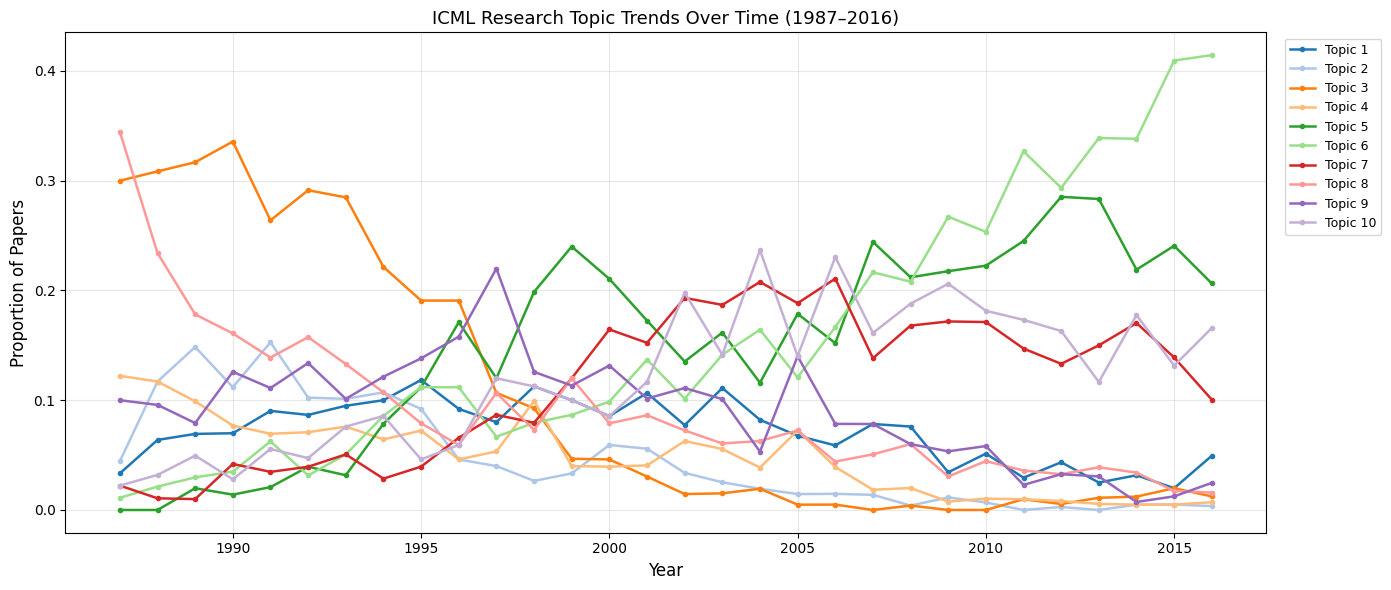

Saved as topic_trends_line.png


In [19]:
# --- Line plot: topic proportion over time ---
colors = plt.cm.tab20.colors

fig, ax = plt.subplots(figsize=(14, 6))
for idx, col in enumerate(pivot.columns):
    ax.plot(pivot.index, pivot[col],
            marker='o', markersize=3,
            label=col,
            color=colors[idx % len(colors)],
            linewidth=1.8)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Proportion of Papers', fontsize=12)
ax.set_title('ICML Research Topic Trends Over Time (1987–2016)', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topic_trends_line.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as topic_trends_line.png")

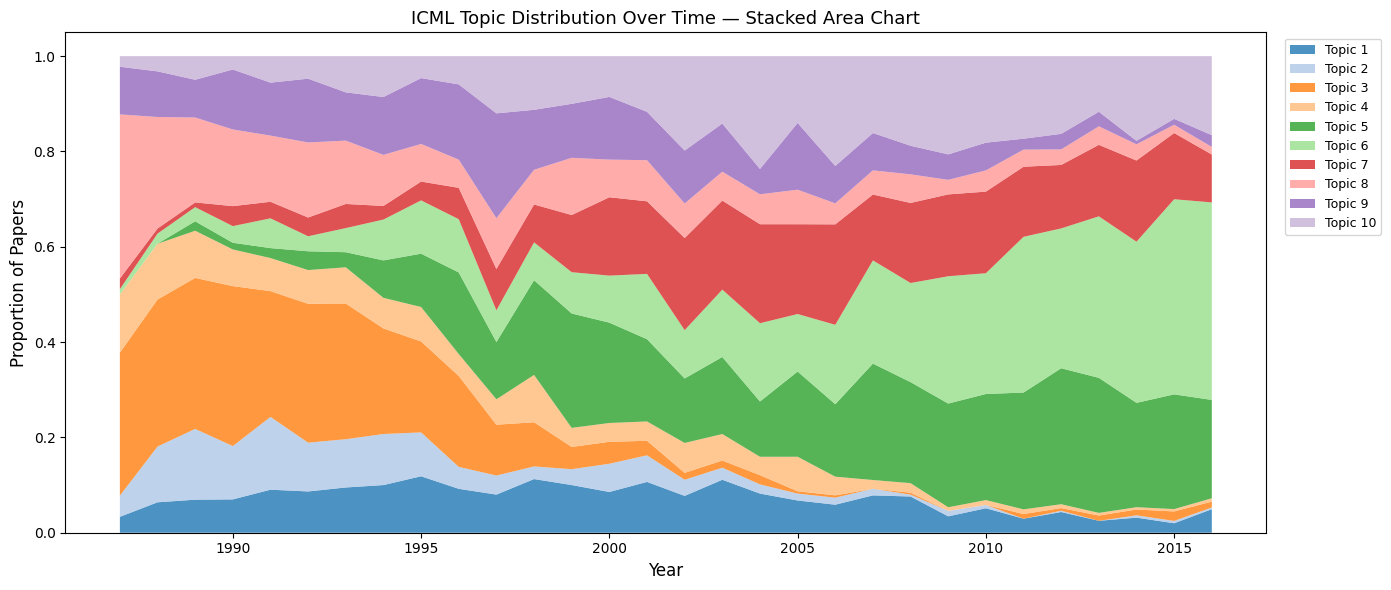

Saved as topic_trends_stacked.png


In [20]:
# --- Stacked area chart ---
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    pivot.index,
    [pivot[col] for col in pivot.columns],
    labels=list(pivot.columns),
    colors=colors[:len(pivot.columns)],
    alpha=0.8
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Proportion of Papers', fontsize=12)
ax.set_title('ICML Topic Distribution Over Time — Stacked Area Chart', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('topic_trends_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as topic_trends_stacked.png")

### 1.3 Discussion: How Research Trends Have Evolved Over Time

The trend plots above reveal a clear and coherent story about how the focus of ICML shifted over 29 years.

**Early era (1987–1993): Neural networks and neuroscience foundations**
The conference began heavily dominated by Topics 3 and 8 — classical neural networks (backpropagation) and computational neuroscience — together accounting for over 60% of papers in 1987. Topic 4 (analog hardware/neuromorphic chips) also held a notable share (~12%), reflecting the excitement about building learning systems in silicon. This is historically accurate: ICML grew out of the Machine Learning community of the 1980s, which was strongly influenced by connectionism and neuroscience.

**Mid-era (1994–2005): The statistical and kernel revolution**
From around 1994, the neural network topics sharply declined. In their place, Topics 5 (Bayesian modelling) and 7 (kernel methods/SVMs) rose steeply, each reaching 15–20% of annual papers by the late 1990s and early 2000s. Topic 6 (learning theory) also grew steadily throughout this period. This perfectly mirrors the well-documented "kernel boom" — the arrival of Support Vector Machines (Vapnik, 1995) shifted the community toward statistical learning theory and kernel-based methods, making probabilistic and geometric approaches the dominant paradigm. Topic 2 (speech recognition) essentially disappeared from ICML after 2005, as that field migrated to dedicated venues and industry.

**Late era (2006–2016): Theory, optimisation, and representation learning**
By 2007, Topic 6 (Learning Theory & Optimization) began surging and became the dominant topic by 2013, reaching 41% of papers in 2015–2016. This is consistent with the era of large-scale machine learning — the need for scalable gradient-based optimisation methods drove enormous theoretical and algorithmic interest. Topic 5 (Bayesian methods) remained stable at 20–28%, indicating that probabilistic reasoning never fell out of favour. Topic 10 (visual feature learning) held steady at 15–20%, reflecting the rise of deep convolutional networks for image-related tasks from around 2012 (AlexNet). Meanwhile, Topics 3, 4, and 8 (the neural hardware/neuroscience cluster) had largely vanished.

**Does this make sense? Yes.** The trends are entirely consistent with the broadly accepted history of machine learning: the backpropagation era of the 1980s, the statistical/kernel era of the late 1990s and 2000s, and the deep learning/optimisation era of the 2010s are all clearly visible in these topic proportions. What is perhaps surprising is how *early* the neuroscience topics were displaced — Topic 8 went from 34% in 1987 to 7% by 1997 — showing how rapidly the field moved away from its biological roots toward mathematical rigour.